In [ ]:
!apt-get update
!apt-get install -y libopencv-dev build-essential cmake

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cli.github.com/packages stable/main amd64 Packages [359 B]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu noble-cran40/ InRelease [3,631 B]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu noble-cran40/ Packages [73.2 kB]
Get:5 http://security.ubuntu.com/ubuntu noble-security InRelease [126 kB]
Hit:6 http://archive.ubuntu.com/ubuntu noble InRelease
Get:7 http://archive.ubuntu.com/ubuntu noble-updates InRelease [126 kB]
Get:8 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64  InRelease [1,578 B]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu noble InRelease [17.8 kB]
Get:10 http://security.ubuntu.com/ubuntu noble-security/restricted amd64 Packages [1,905 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu noble InRelease [9,161 B]
Hit:12 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu noble InRelease
Get:13 http://archive.ubuntu.com/ubuntu noble-backports 

In [ ]:
%%writefile main.cpp
#include <iostream>
#include <opencv2/opencv.hpp>
#include <cuda_runtime.h>

int main() {
    std::cout << "--- Sistem Bilgileri ---" << std::endl;
    std::cout << "OpenCV Versiyonu: " << CV_VERSION << std::endl;

    int deviceCount = 0;
    cudaError_t error = cudaGetDeviceCount(&deviceCount);

    if (error == cudaSuccess && deviceCount > 0) {
        std::cout << "CUDA Durumu: Başarılı! Colab GPU Algılandı." << std::endl;
        std::cout << "Algılanan GPU Sayısı: " << deviceCount << std::endl;
    } else {
        std::cout << "CUDA Durumu: Cihaz bulunamadı veya GPU aktif değil!" << std::endl;
    }

    return 0;
}

Writing main.cpp


In [ ]:
!g++ main.cpp -o app `pkg-config --cflags --libs opencv4` -I/usr/local/cuda/include -L/usr/local/cuda/lib64 -lcudart
!./app

--- Sistem Bilgileri ---
OpenCV Versiyonu: 4.6.0
CUDA Durumu: Başarılı! Colab GPU Algılandı.
Algılanan GPU Sayısı: 1


In [ ]:
%%writefile main.cpp
#include <iostream>
#include <vector>
#include <thread> // Çekirdekler (Threads) için gerekli kütüphane
#include <opencv2/opencv.hpp>

// Her bir çekirdeğin (thread) çalıştıracağı fonksiyon
void processROI(cv::Mat roi, int thread_id) {
    // Çekirdek kendisine verilen ROI matrisinin piksellerini gezer
    for (int y = 0; y < roi.rows; y++) {
        for (int x = 0; x < roi.cols; x++) {
            uchar pixel = roi.at<uchar>(y, x);
            // Parlaklık değerini 4'e bölüp 4 ile çarpıyoruz
            roi.at<uchar>(y, x) = (pixel / 4) * 4;
        }
    }
    std::cout << "Cekirdek " << thread_id << " parcasini islemeyi tamamladi." << std::endl;
}

int main() {
    // 1. Resmi Tek Kanallı (Grayscale) yükle
    cv::Mat img = cv::imread("resim.jpg", cv::IMREAD_GRAYSCALE);

    if (img.empty()) {
        std::cout << "HATA: resim.jpg bulunamadi!" << std::endl;
        return -1;
    }

    // Resmin boyutlarını ve orta noktalarını bulalım
    int width = img.cols;
    int height = img.rows;
    int half_w = width / 2;
    int half_h = height / 2;

    // 2. Resmi 4 Eşit ROI (Alt Matris) Bölgesine Ayırma
    // cv::Rect(x, y, genislik, yukseklik)
    cv::Mat roi1 = img(cv::Rect(0, 0, half_w, half_h));           // Sol-Üst
    cv::Mat roi2 = img(cv::Rect(half_w, 0, half_w, half_h));      // Sağ-Üst
    cv::Mat roi3 = img(cv::Rect(0, half_h, half_w, half_h));      // Sol-Alt
    cv::Mat roi4 = img(cv::Rect(half_w, half_h, half_w, half_h)); // Sağ-Alt

    // 3. 4 Farklı Çekirdek (Thread) Oluşturup Her Parçayı Ayrı Çekirdeğe Verme
    std::thread t1(processROI, roi1, 1);
    std::thread t2(processROI, roi2, 2);
    std::thread t3(processROI, roi3, 3);
    std::thread t4(processROI, roi4, 4);

    // 4. Tüm çekirdeklerin işini bitirmesini bekle (Sync)
    t1.join();
    t2.join();
    t3.join();
    t4.join();

    // 5. İşlenmiş resmi kaydet
    cv::imwrite("paralel_sonuc.jpg", img);
    std::cout << "\nTum parcalar paralel olarak islendi ve 'paralel_sonuc.jpg' kaydedildi!" << std::endl;

    return 0;
}

Overwriting main.cpp


In [ ]:
!g++ main.cpp -o app `pkg-config --cflags --libs opencv4` -lpthread
!./app

Cekirdek 1 parcasini islemeyi tamamladi.
Cekirdek 3 parcasini islemeyi tamamladi.
Cekirdek 2 parcasini islemeyi tamamladi.
Cekirdek 4 parcasini islemeyi tamamladi.

Tum parcalar paralel olarak islendi ve 'paralel_sonuc.jpg' kaydedildi!


--- PARALEL İŞLENMİŞ (ROI + THREAD) RESİM ---


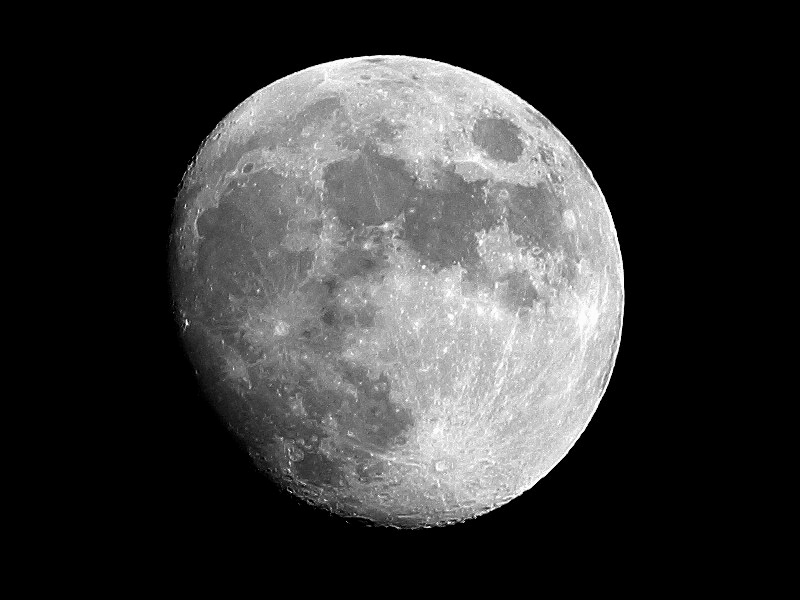

In [ ]:
import cv2
from google.colab.patches import cv2_imshow

print("--- PARALEL İŞLENMİŞ (ROI + THREAD) RESİM ---")
cv2_imshow(cv2.imread('paralel_sonuc.jpg', cv2.IMREAD_GRAYSCALE))

In [ ]:
%%writefile main.cpp
#include <iostream>
#include <vector>
#include <thread>
#include <opencv2/opencv.hpp>

// Her çekirdek kendi bölgesine (ROI) farklı bir işlem uygular
void processROI(cv::Mat roi, int thread_id) {
    for (int y = 0; y < roi.rows; y++) {
        for (int x = 0; x < roi.cols; x++) {
            uchar pixel = roi.at<uchar>(y, x);

            if (thread_id == 1) {
                // Sol-Üst Parça: İyice karart
                roi.at<uchar>(y, x) = pixel / 4;
            }
            else if (thread_id == 2) {
                // Sağ-Üst Parça: İyice parlat
                roi.at<uchar>(y, x) = std::min(255, pixel + 80);
            }
            else if (thread_id == 3) {
                // Sol-Alt Parça: Negatifini al (Renkleri ters çevir)
                roi.at<uchar>(y, x) = 255 - pixel;
            }
            else if (thread_id == 4) {
                // Sağ-Alt Parça: 4'e böl 4 ile çarp (Detay kaybı)
                roi.at<uchar>(y, x) = (pixel / 4) * 4;
            }
        }
    }
}

int main() {
    cv::Mat img = cv::imread("resim.jpg", cv::IMREAD_GRAYSCALE);

    if (img.empty()) {
        std::cout << "HATA: resim.jpg bulunamadi!" << std::endl;
        return -1;
    }

    int half_w = img.cols / 2;
    int half_h = img.rows / 2;

    // 1. Resmi 4 parçaya (ROI) ayırıyoruz
    cv::Mat roi1 = img(cv::Rect(0, 0, half_w, half_h));           // Sol-Üst
    cv::Mat roi2 = img(cv::Rect(half_w, 0, half_w, half_h));      // Sağ-Üst
    cv::Mat roi3 = img(cv::Rect(0, half_h, half_w, half_h));      // Sol-Alt
    cv::Mat roi4 = img(cv::Rect(half_w, half_h, half_w, half_h)); // Sağ-Alt

    // 2. Her parçayı AYRI BİR ÇEKİRDEĞE veriyoruz
    std::thread t1(processROI, roi1, 1);
    std::thread t2(processROI, roi2, 2);
    std::thread t3(processROI, roi3, 3);
    std::thread t4(processROI, roi4, 4);

    t1.join();
    t2.join();
    t3.join();
    t4.join();

    // Bölünme sınırlarını kırmızı/beyaz çizgilerle belirginleştirelim
    cv::line(img, cv::Point(half_w, 0), cv::Point(half_w, img.rows), cv::Scalar(255), 3);
    cv::line(img, cv::Point(0, half_h), cv::Point(img.cols, half_h), cv::Scalar(255), 3);

    cv::imwrite("paralel_sonuc.jpg", img);
    std::cout << "Islem tamamlandi! 4 farkli parcanin degisimini gorebilirsiniz." << std::endl;

    return 0;
}

Overwriting main.cpp


In [ ]:
!g++ main.cpp -o app `pkg-config --cflags --libs opencv4` -lpthread
!./app

Islem tamamlandi! 4 farkli parcanin degisimini gorebilirsiniz.


--- PARALEL İŞLENMİŞ (ROI + THREAD) RESİM ---


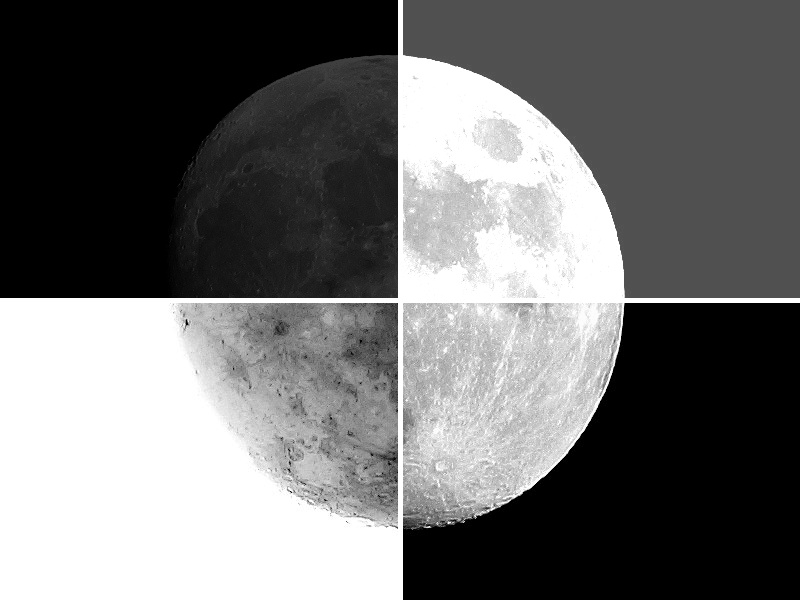

In [ ]:
import cv2
from google.colab.patches import cv2_imshow

print("--- PARALEL İŞLENMİŞ (ROI + THREAD) RESİM ---")
cv2_imshow(cv2.imread('paralel_sonuc.jpg', cv2.IMREAD_GRAYSCALE))